# Notebook 02 · Proxy Validation and Lag Screening

**Goal:** Rank candidate environmental regressors for the target variable (e.g., `absinc`) using Pearson correlation and lagged cross-correlation screening. Since the timeseries are already stationary, we focus solely on Pearson correlation to understand the best fit and determine optimal thermal inertia lags.

**Steps:**
1. **Load Aligned Data** — Load the dataset from Notebook 01.
2. **Initial Pearson Correlation** — Check immediate linear relationships between the target and proxies.
3. **Lag Screening** — Sweep through time lags to find the maximum cross-correlation (thermal memory).
4. **Feature Matrix Generation** — Align proxies with their optimal lags and save as a Parquet feature matrix for modeling.

In [22]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath('..'))
from heritageshm.diagnostics import shift_and_correlate, test_signal_stationarity
from heritageshm.viz import apply_theme

apply_theme(context='notebook')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH   = "data/interim/aligned/st02_aligned_dataset.csv"
OUTPUT_PATH = "data/processed/feature_matrix.csv"
FIG_PATH    = "outputs/figures/"

# ── Config ────────────────────────────────────────────────────────────────────
TARGET      = "absinc"
MAX_LAG_H   = 12          # maximum lag to screen (hours); 72h = 3 days thermal memory
LAG_STEP    = 1           # step in hours

## Step 1 · Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
df.index = pd.to_datetime(df.datetime)

# Drop non-proxy columns like charge or duplicate variables
EXCLUDE  = ["charge", "datetime", "temp", "hum", "oikolab_wind_speed (m/s)", "oikolab_wind_direction (deg)", "oikolab_total_cloud_cover (0-1)", TARGET]
proxies  = [c for c in df.columns if c not in EXCLUDE]

print(f"Loaded: {df.shape[0]} rows | {df.index[0]} → {df.index[-1]}")
print(f"Target : {TARGET}")
print(f"Proxies: {proxies}")
display(df[[TARGET] + proxies].describe().T)

Loaded: 57278 rows | 2018-07-25 23:00:00 → 2025-02-05 12:00:00
Target : absinc
Proxies: ['temperature (degC)', 'dewpoint_temperature (degC)', 'relative_humidity (0-1)', 'wetbulb_temperature (degC)', 'skin_temperature (degC)', 'urban_temperature (degC)', 'surface_solar_radiation (W/m^2)', 'surface_thermal_radiation (W/m^2)']


,count,mean,std,min,25%,50%,75%,max
absinc,39775.0,114.146001,52.153965,-53.45,84.8125,110.975,155.220833,231.80
temperature (degC),57278.0,13.619411,7.938618,-9.98,7.6100,12.860,19.330000,36.11
dewpoint_temperature (degC),57278.0,8.402467,6.144757,-14.63,4.1400,8.750,13.390000,22.10
relative_humidity (0-1),57278.0,0.735117,0.174166,0.18,0.6100,0.770,0.880000,1.00
wetbulb_temperature (degC),57278.0,10.452150,6.327203,-10.76,5.7000,10.380,15.710000,24.43
skin_temperature (degC),57278.0,13.464605,9.299911,-15.45,6.5300,12.520,19.530000,42.21
urban_temperature (degC),57278.0,14.425468,7.942013,-7.32,8.1500,13.560,20.750000,34.50
surface_solar_radiation (W/m^2),57278.0,171.345266,247.406748,0.00,0.0000,6.240,296.747500,945.36
surface_thermal_radiation (W/m^2),57278.0,318.925681,43.050782,198.22,288.4500,323.140,351.730000,431.26


### Visualizing Target vs. Proxies
Let's plot the target variable alongside each proxy to visually inspect their relationships over time.

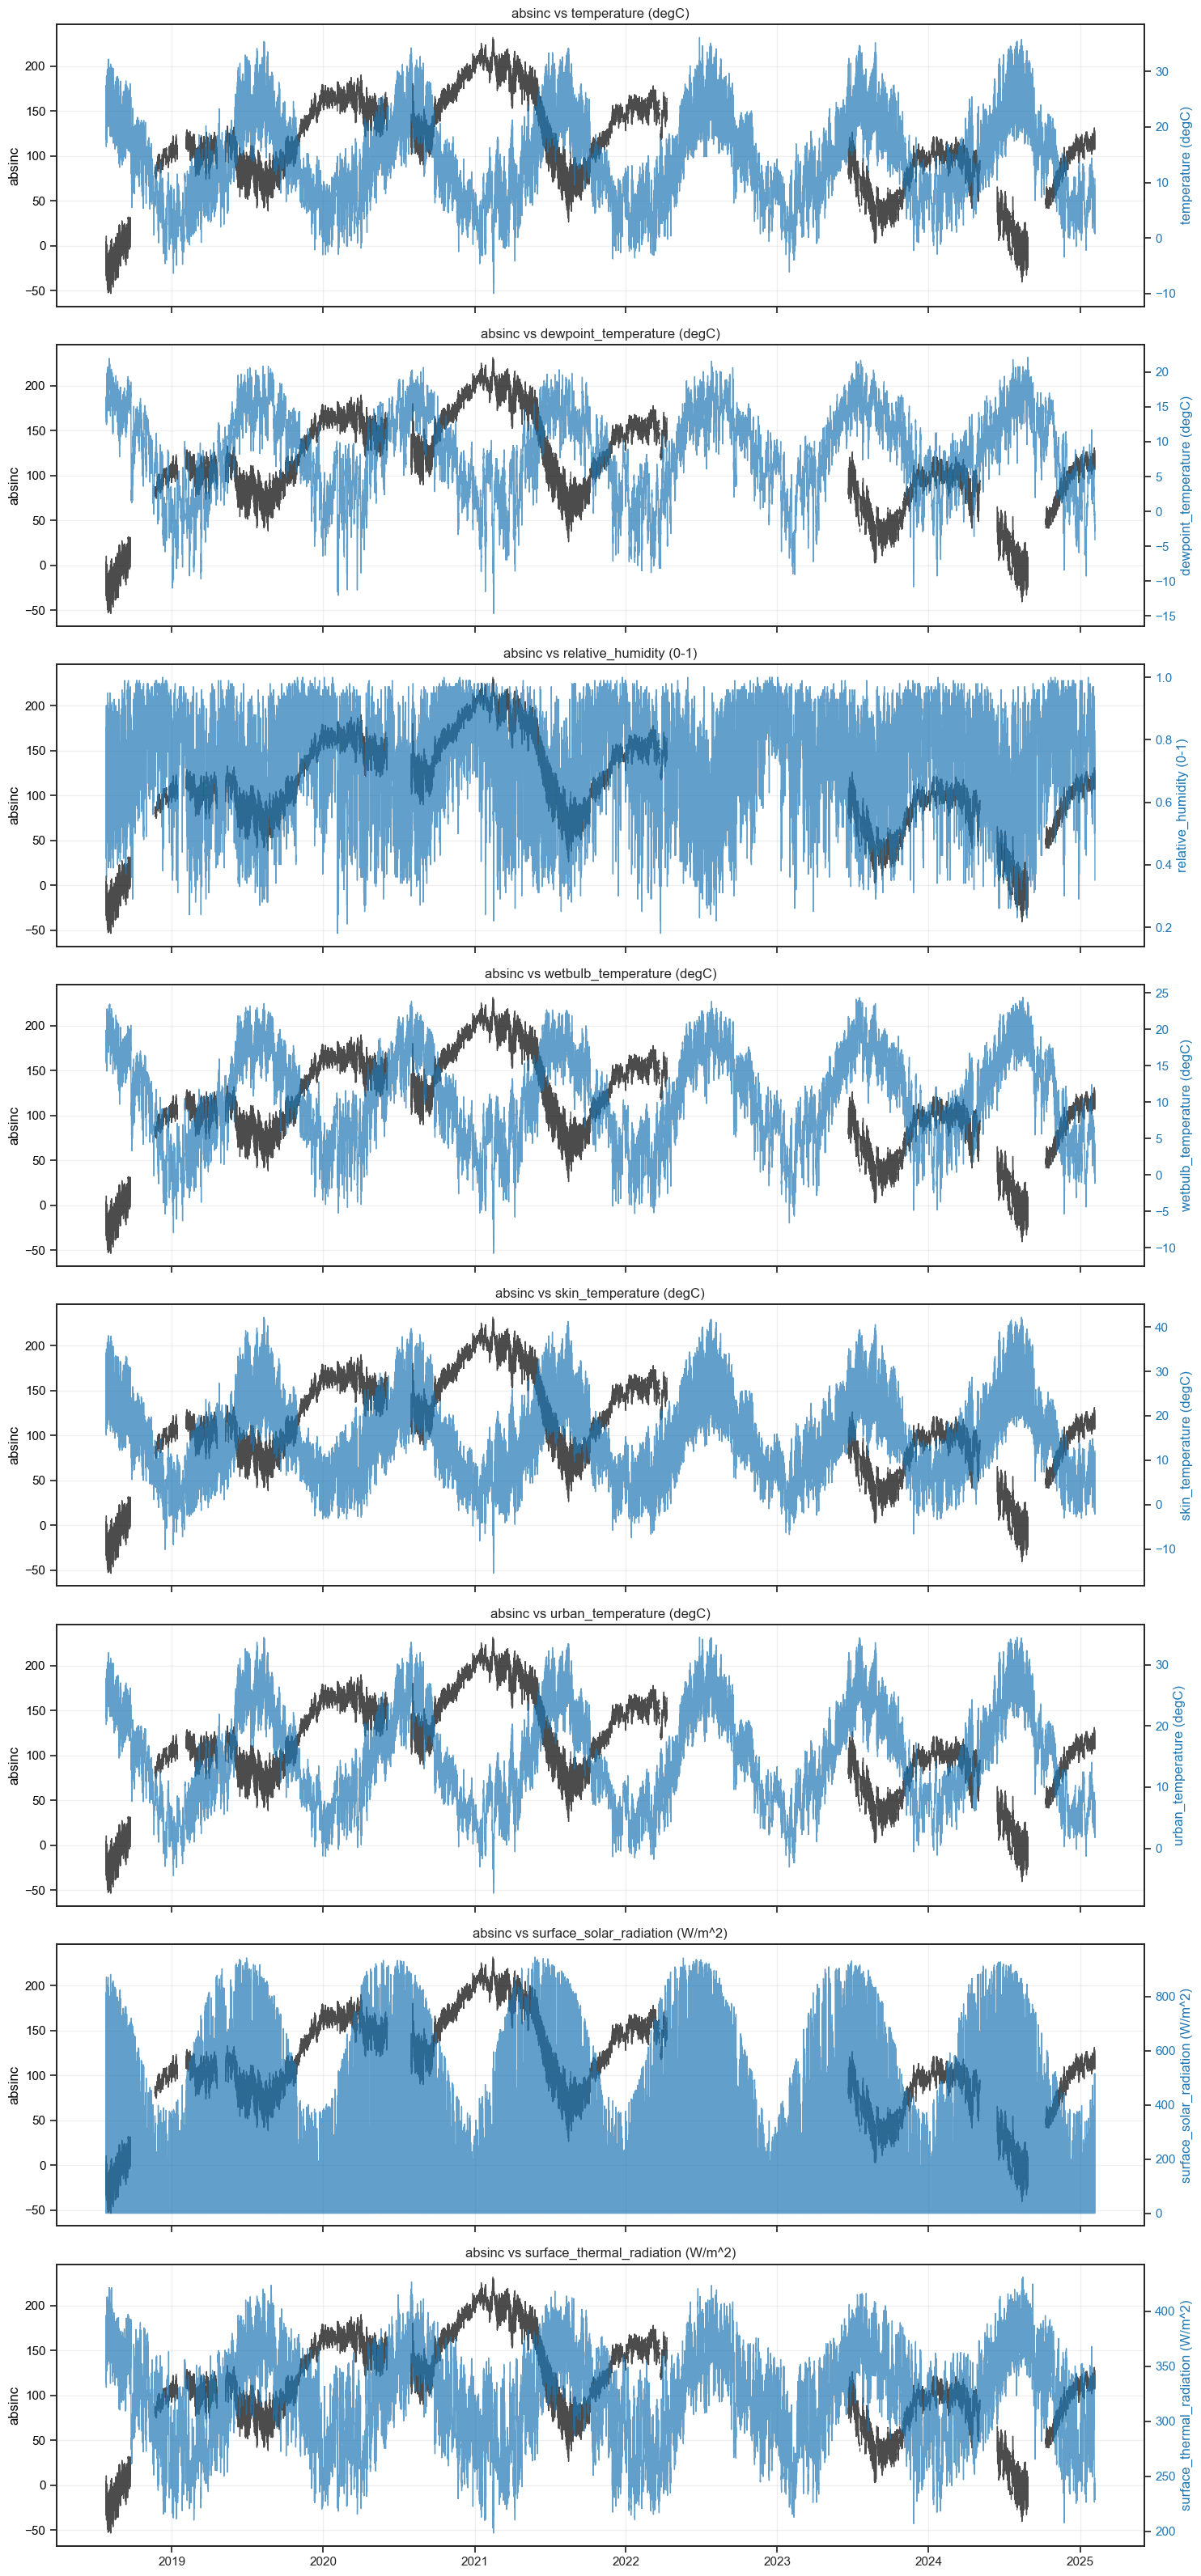

In [6]:
fig, axes = plt.subplots(len(proxies), 1, figsize=(15, 4 * len(proxies)), sharex=True)
if len(proxies) == 1:
    axes = [axes]

for ax, proxy in zip(axes, proxies):
    # Plot Target
    color_target = 'black'
    ax.plot(df.index, df[TARGET], label=TARGET, color=color_target, alpha=0.7, linewidth=1)
    ax.set_ylabel(TARGET, color=color_target)
    ax.tick_params(axis='y', labelcolor=color_target)
    
    # Plot Proxy on twin axis
    ax2 = ax.twinx()
    color_proxy = 'tab:blue'
    ax2.plot(df.index, df[proxy], label=proxy, color=color_proxy, alpha=0.7, linewidth=1)
    ax2.set_ylabel(proxy, color=color_proxy)
    ax2.tick_params(axis='y', labelcolor=color_proxy)
    
    ax.set_title(f"{TARGET} vs {proxy}")
    ax.grid(True, alpha=0.3)
    
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

## Step 1b · Reference Window and Differenced Series

**Reference window.** The target signal contains gaps of varying length. The analysis is restricted to the longest contiguous non-missing block of the target variable, identified by detecting time jumps larger than 1.5× the expected sampling step. The boundaries of this window — `REF_START` and `REF_END` — are stored as constants for reuse in Notebook 04 as the model training period.

**First-order differencing.** All variables within the reference window are first-differenced before Pearson correlation and lag screening. This conservative transformation guarantees stationarity regardless of the individual integration order of each series, eliminating the risk of spurious correlation. Differencing is applied exclusively for proxy ranking and lag identification; the level series
`df_ref` is preserved and used for feature matrix assembly in Step 4.

In [7]:
# --- Identify longest contiguous non-missing block of the target ---
target_series = df[TARGET].dropna()

expected_step = pd.Timedelta('1h')  # must match TARGET_FREQ from Notebook 01
time_diffs = target_series.index.to_series().diff()
breaks = time_diffs[time_diffs > expected_step * 1.5].index

block_starts = [target_series.index[0]] + list(breaks)
block_ends   = list(breaks - expected_step) + [target_series.index[-1]]
block_lengths_h = [(e - s).total_seconds() / 3600 for s, e in zip(block_starts, block_ends)]

longest_idx = int(pd.Series(block_lengths_h).idxmax())
REF_START   = block_starts[longest_idx]
REF_END     = block_ends[longest_idx]

print(f"Longest contiguous block : {REF_START} → {REF_END}")
print(f"Duration                 : {block_lengths_h[longest_idx]:.0f} h "
      f"({block_lengths_h[longest_idx] / 24:.1f} days)")

# Slice to reference window
df_ref = df.loc[REF_START:REF_END].copy()

# --- Build first-differenced DataFrame for correlation screening ---
df_diff = df_ref[[TARGET] + proxies].diff().dropna()

print(f"\nReference window shape   : {df_ref.shape}")
print(f"Differenced shape        : {df_diff.shape}")

Longest contiguous block : 2022-03-29 19:00:00 → 2023-06-21 12:00:00
Duration                 : 10769 h (448.7 days)

Reference window shape   : (10770, 13)
Differenced shape        : (268, 9)


## Step 2 · Initial Pearson Correlation
Since our timeseries are already stationary, we screen for immediate linear relationships.

In [8]:
# Calculate Pearson correlation for all proxies
initial_corrs = df_diff.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("--- Initial Pearson Correlation (Lag 0) ---")
print(initial_corrs)

--- Initial Pearson Correlation (Lag 0) ---
urban_temperature (degC)            -0.510402
temperature (degC)                  -0.483304
relative_humidity (0-1)              0.429415
skin_temperature (degC)             -0.407972
wetbulb_temperature (degC)          -0.396654
surface_solar_radiation (W/m^2)     -0.355159
dewpoint_temperature (degC)         -0.100358
surface_thermal_radiation (W/m^2)   -0.055228
Name: absinc, dtype: float64


## Step 3 · Lag Screening (Thermal Inertia)
Structural responses to environmental conditions (like temperature) are typically delayed due to thermal inertia. By screening shifted cross-correlations, we align the proxy optimally with the target.

temperature (degC): Optimal Lag = 1h, r = -0.509
dewpoint_temperature (degC): Optimal Lag = 2h, r = -0.326
relative_humidity (0-1): Optimal Lag = 0h, r = 0.429
wetbulb_temperature (degC): Optimal Lag = 1h, r = -0.488
skin_temperature (degC): Optimal Lag = 2h, r = -0.541
urban_temperature (degC): Optimal Lag = 0h, r = -0.510
surface_solar_radiation (W/m^2): Optimal Lag = 1h, r = -0.474
surface_thermal_radiation (W/m^2): Optimal Lag = 11h, r = 0.078


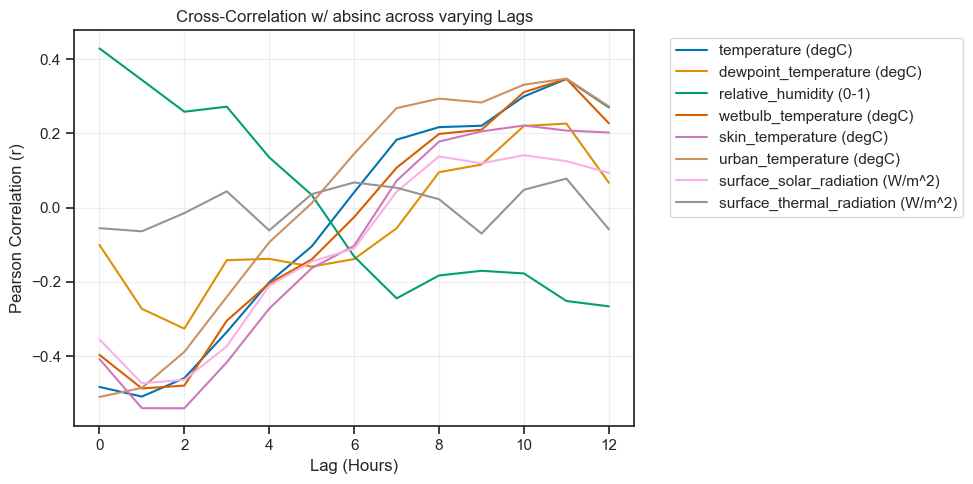

In [20]:
optimal_lags = {}
plt.figure(figsize=(10, 5))

for proxy in proxies:
    lags, corrs = shift_and_correlate(df_diff, TARGET, proxy, MAX_LAG_H, LAG_STEP)
    
    # Find lag with maximum absolute correlation
    max_idx = np.argmax(np.abs(corrs))
    best_lag = lags[max_idx]
    best_corr = corrs[max_idx]
    
    optimal_lags[proxy] = best_lag
    
    print(f"{proxy}: Optimal Lag = {best_lag}h, r = {best_corr:.3f}")
    plt.plot(lags, corrs, label=proxy)

plt.title(f"Cross-Correlation w/ {TARGET} across varying Lags")
plt.xlabel("Lag (Hours)")
plt.ylabel("Pearson Correlation (r)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 · Assemble Feature Matrix
Shift the proxies by their optimal lags to construct the final dataset.

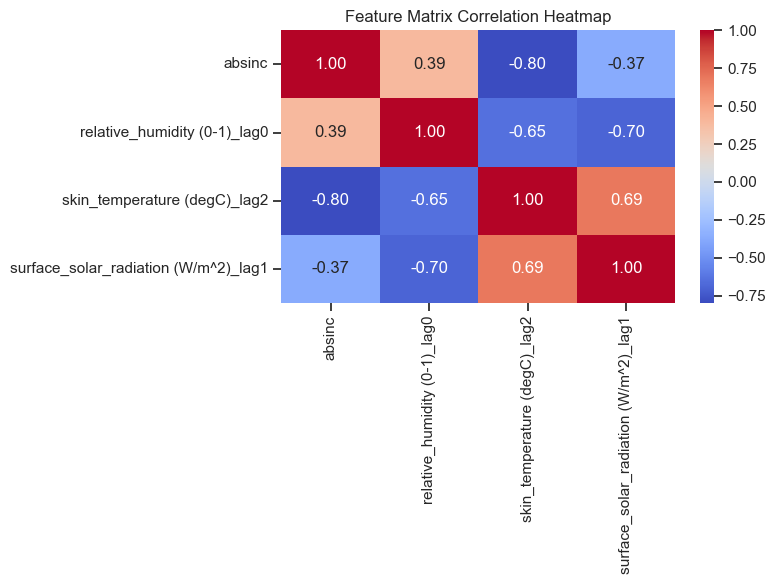


Saved feature matrix: (267, 4)
Path: data/processed/feature_matrix.csv


In [24]:
# Drop proxies excluded from the feature matrix
EXCLUDE_FROM_FEATURES = [
    'surface_thermal_radiation (W/m^2)',
    'urban_temperature (degC)',
    'wetbulb_temperature (degC)',
    'dewpoint_temperature (degC)',
    'temperature (degC)',
]
optimal_lags_filtered = {k: v for k, v in optimal_lags.items() if k not in EXCLUDE_FROM_FEATURES}

# Assemble feature matrix from level series using optimal lags
df_features = df_ref[[TARGET]].copy()

for proxy, lag in optimal_lags_filtered.items():
    col_name = f"{proxy}_lag{lag}"
    df_features[col_name] = df_ref[proxy].shift(lag)

df_features = df_features.dropna()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Matrix Correlation Heatmap")
plt.tight_layout()
plt.show()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df_features.to_csv(OUTPUT_PATH)
print(f"\nSaved feature matrix: {df_features.shape}")
print(f"Path: {OUTPUT_PATH}")